# Modelling with and without embeddings
- fit and make predictions with xgb model on dataset with and on dataset without embeddings
- plot feature importance to take insights

## Imports

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, plot_importance
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

## Read dataset

In [72]:
data = pd.read_csv("../data/processed/08. FRAIL_embeddings_5dim.csv")
print(data.shape)
data.head()

(6705, 96)


,ID_Aluno,Momento,Local_de_Avaliacao,Data_avaliacao,Data_nascimento,Age,Genero,Modalidade,Freq_semanal,ANTROPOMETRIA_Estatura_cm,...,6Min_ParouMot_Emb_0,6Min_ParouMot_Emb_1,6Min_ParouMot_Emb_2,6Min_ParouMot_Emb_3,6Min_ParouMot_Emb_4,6Min_Desistiu_Emb_0,6Min_Desistiu_Emb_1,6Min_Desistiu_Emb_2,6Min_Desistiu_Emb_3,6Min_Desistiu_Emb_4
0,19,1,1,2021-11-16,1941-08-20,80,0,1,2,153.0,...,0.116997,0.129492,-0.136998,-0.06721,0.059389,0.116997,0.129492,-0.136998,-0.06721,0.059389
1,19,3,1,2022-11-16,1941-08-20,81,0,1,2,152.0,...,0.116997,0.129492,-0.136998,-0.06721,0.059389,0.116997,0.129492,-0.136998,-0.06721,0.059389
2,37,1,1,2021-11-16,1948-11-20,72,0,1,2,149.0,...,0.116997,0.129492,-0.136998,-0.06721,0.059389,0.116997,0.129492,-0.136998,-0.06721,0.059389
3,37,2,1,2022-06-29,1948-11-20,73,0,1,2,150.0,...,0.116997,0.129492,-0.136998,-0.06721,0.059389,0.116997,0.129492,-0.136998,-0.06721,0.059389
4,37,3,1,2022-11-16,1948-11-20,73,0,1,2,148.0,...,0.116997,0.129492,-0.136998,-0.06721,0.059389,0.116997,0.129492,-0.136998,-0.06721,0.059389


## Feature selection

In [73]:
data = data.drop(columns = ["Data_avaliacao", "Local_de_Avaliacao", "Data_nascimento",
                            "Quedas_12meses_Situacao", "Quedas_12meses_Lesao_Tipo",
                            "Quedas_12meses_Lesao_Local", "@6_MIN_ANDAR_Parou_Motivo",
                            "@6_MIN_ANDAR_Desistiu",
                            ])

## XGBoost

In [74]:
X = data.drop(columns="Quedas_12meses_Medo_cair_Sim_Não")
y = data['Quedas_12meses_Medo_cair_Sim_Não']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

# Define the model
model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.71      0.70      1104
           1       0.63      0.61      0.62       908

    accuracy                           0.66      2012
   macro avg       0.66      0.66      0.66      2012
weighted avg       0.66      0.66      0.66      2012



<Figure size 1000x800 with 0 Axes>

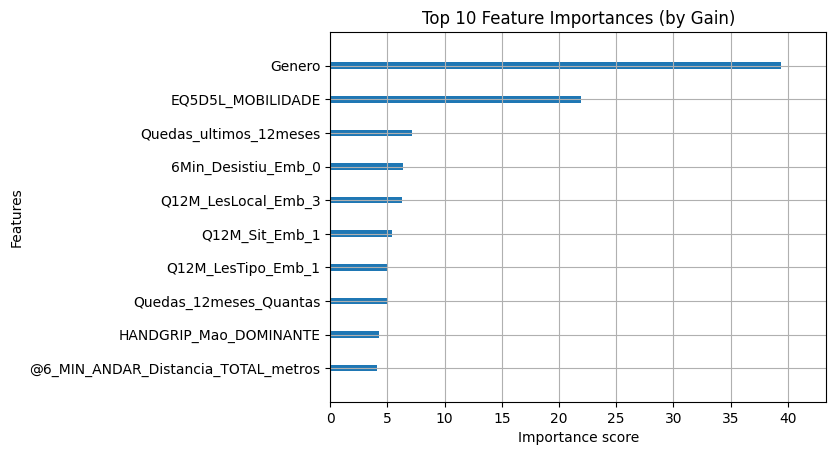

In [75]:
# Plot feature importance
plt.figure(figsize=(10, 8))
plot_importance(model, max_num_features=10, importance_type='gain', show_values=False)
plt.title('Top 10 Feature Importances (by Gain)')
plt.show()

## Random Forest

In [76]:
# Random Forest model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.77      0.73      1104
           1       0.68      0.59      0.63       908

    accuracy                           0.69      2012
   macro avg       0.69      0.68      0.68      2012
weighted avg       0.69      0.69      0.69      2012

